<a href="https://colab.research.google.com/github/djwillichile/geoia-bloom-huasco/blob/main/notebooks/cartografia_huasco_layout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>

# 🗺️ Layout Cartográfico — Cuenca del Huasco
**Elevación (SRTM) · NDVI medio (MODIS) · Cuenca · Región de Atacama**

</div>

## 0 · Dependencias
> Solo instala lo que falte — no requiere reiniciar el runtime.

In [10]:
!apt-get update -qq
!apt-get install -y -qq libproj-dev proj-data proj-bin libgeos-dev

import importlib.util
import subprocess
import sys


def install_if_missing(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name

    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {pip_name}...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name
        ])
        print(f"✅ {pip_name} instalado")
    else:
        print(f"✅ {pip_name} ya está disponible")


packages = [
    ("ee", "earthengine-api"),
    ("geemap", "geemap"),
    ("matplotlib_scalebar", "matplotlib-scalebar"),
    ("cartopy", "cartopy"),
    ("cairosvg", "cairosvg"),
    ("geopandas", "geopandas"),
    ("PIL", "Pillow"),
]

for import_name, pip_name in packages:
    install_if_missing(import_name, pip_name)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ earthengine-api ya está disponible
✅ geemap ya está disponible
✅ matplotlib-scalebar ya está disponible
✅ cartopy ya está disponible
✅ cairosvg ya está disponible
✅ geopandas ya está disponible
✅ Pillow ya está disponible


## 1 · Imports e inicialización de Earth Engine
> El proyecto se lee desde los **Secrets de Colab** (`🔑 → projectGEE`). Si no lo tienes configurado, reemplaza `userdata.get(...)` por el string de tu proyecto directamente.

In [11]:
import ee, geemap, numpy as np, warnings, requests
import geopandas as gpd
from shapely.geometry import shape
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from google.colab import userdata
import os
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

warnings.filterwarnings('ignore')

# ── Leer proyecto desde Secrets ───────────────────────────────────────────────
try:
    PROJECT_ID = userdata.get('projectGEE')
except Exception:
    PROJECT_ID = None

# Si no está en Secrets, pedir manualmente
if not PROJECT_ID:
    print('⚠️  No se encontró el Secret "projectGEE".')
    print('   Opciones:')
    print('   1) Agrega tu proyecto en el panel 🔑 (Secrets) con clave: projectGEE')
    print('   2) O ingrésalo manualmente a continuación:\n')
    PROJECT_ID = input('   Ingresa tu Google Cloud Project ID: ').strip()

# ── Inicializar Earth Engine ──────────────────────────────────────────────────
try:
    ee.Initialize(project=PROJECT_ID)
    print('✅ Earth Engine inicializado correctamente.')
except Exception:
    print('Autenticando...')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print('✅ Earth Engine inicializado tras autenticación.')

✅ Earth Engine inicializado correctamente.


In [12]:
# ── Regiones de contexto (Atacama y Coquimbo) ─────────────────────────────────
regiones = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.inList('ADM1_NAME', ['Atacama', 'Coquimbo']))
)

# ── Provincia y cuenca del Huasco ─────────────────────────────────────────────
gaul = ee.FeatureCollection('FAO/GAUL/2015/level2')

huasco_prov = (
    gaul
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Huasco'))
    .geometry()
)

outlet       = ee.Geometry.Point([-71.17, -28.47])
basins       = ee.FeatureCollection('WWF/HydroSHEDS/v1/Basins/hybas_6')
huasco_basin = ee.Feature(basins.filterBounds(outlet).first()).geometry()

# ── AOI: unión provincia + cuenca con buffer 5 km ─────────────────────────────
AOI = huasco_basin.union(huasco_prov).bounds().buffer(5000).bounds()

# ── GeoDataFrames ─────────────────────────────────────────────────────────────
huasco_gdf = gpd.GeoDataFrame(
    geometry=[shape(huasco_basin.getInfo())],
    crs='EPSG:4326'
)
regiones_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in regiones.getInfo()['features']],
    crs='EPSG:4326'
)

# ── Ríos HydroSHEDS (orden 1–5) ───────────────────────────────────────────────
# RIV_ORD: 1 = río más grande, 10 = más pequeño
# Bajar a lte(7) si faltan ríos, subir a lte(4) si hay exceso
rios_region = (
    ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers')
    .filterBounds(regiones.geometry())
    .filter(ee.Filter.lte('RIV_ORD', 6))
    .limit(500)
)
rios_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in rios_region.getInfo()['features']],
    crs='EPSG:4326'
)

print(f'Regiones    — features: {len(regiones_gdf)}')   # debe ser 2
print(f'Prov Huasco — área > 0: {huasco_prov.area().getInfo() > 0}')
print(f'Ríos región — features: {len(rios_gdf)}')
print('✅ Geometrías y AOI listos')

Regiones    — features: 2
Prov Huasco — área > 0: True
Ríos región — features: 420
✅ Geometrías y AOI listos


## 3 · Capas GEE — DEM hillshade y NDVI

In [13]:
# ── DEM + Hillshade (SRTM 30 m) ───────────────────────────────────────────────
dem       = ee.Image('USGS/SRTMGL1_003').clip(AOI)
hillshade = ee.Terrain.hillshade(dem)

elev_vis = {
    'min': -120, 'max': 4600,
    'palette': [
        '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
        '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
        '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
        '#f6e8c3', '#f5f5f5'
    ]
}

rgb    = dem.visualize(**elev_vis)
shaded = ee.Image.rgb(
    rgb.select(0).multiply(hillshade.divide(255)),
    rgb.select(1).multiply(hillshade.divide(255)),
    rgb.select(2).multiply(hillshade.divide(255))
)

# ── NDVI medio período de floración ───────────────────────────────────────────
# ⚠️ Ajusta meses según tu análisis del desierto florido
MONTH_START, MONTH_END = 7, 10
YEAR_START,  YEAR_END  = 2002, 2023

ndvi_mean = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate(f'{YEAR_START}-01-01', f'{YEAR_END}-12-31')
    .filter(ee.Filter.calendarRange(MONTH_START, MONTH_END, 'month'))
    .select('NDVI')
    .map(lambda img: img.multiply(0.0001))
    .mean()
    .clip(AOI)
)

# ── NDVI enmascarado a la cuenca + hillshade ──────────────────────────────────
vis_ndvi = {
    'min': 0.0, 'max': 0.9,
    'palette': [
        '#ffffff', '#ce7e45', '#df923d', '#f1b555', '#fcd163', '#99b718',
        '#74a901', '#66a000', '#529400', '#3e8601', '#207401', '#056201',
        '#004c00', '#023b01', '#012e01', '#011d01', '#011301'
    ]
}

ndvi_cuenca = ndvi_mean.updateMask(
    ee.Image.constant(1).clip(huasco_basin).mask()
)
ndvi_rgb = ndvi_cuenca.visualize(**vis_ndvi)
ndvi_shaded = ee.Image.rgb(
    ndvi_rgb.select(0).multiply(hillshade.divide(255)),
    ndvi_rgb.select(1).multiply(hillshade.divide(255)),
    ndvi_rgb.select(2).multiply(hillshade.divide(255))
)

print('✅ DEM con hillshade y NDVI procesados.')

✅ DEM con hillshade y NDVI procesados.


## 4 · Descarga de arrays
> `shaded` y `ndvi_shaded` via `getThumbURL`. DEM escalar a 500 m para curvas de nivel.

In [14]:
RES_DEM = 200

# ── Extensión del AOI ─────────────────────────────────────────────────────────
aoi_coords = AOI.bounds().getInfo()['coordinates'][0]
lons = [c[0] for c in aoi_coords]
lats = [c[1] for c in aoi_coords]
dem_ext  = [min(lons), max(lons), min(lats), max(lats)]
ndvi_ext = dem_ext

# ── Shaded DEM via getThumbURL ────────────────────────────────────────────────
thumb_url = shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 1200,
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
shaded_2d = np.array(Image.open(BytesIO(requests.get(thumb_url).content)).convert('RGB'))

# ── NDVI enmascarado via getThumbURL (RGBA) ───────────────────────────────────
ndvi_url = ndvi_shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 800,
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
ndvi_2d = np.array(Image.open(BytesIO(requests.get(ndvi_url).content)).convert('RGBA'))

# Transparencia en píxeles blancos (fuera de máscara de cuenca)
es_blanco = (ndvi_2d[:,:,0] > 240) & (ndvi_2d[:,:,1] > 240) & (ndvi_2d[:,:,2] > 240)
ndvi_2d[es_blanco, 3] = 0

# ── DEM escalar para curvas de nivel (500 m) ──────────────────────────────────
dem_arr = geemap.ee_to_numpy(dem, region=AOI, scale=500)
dem_2d  = dem_arr[:,:,0] if dem_arr.ndim == 3 else dem_arr

print(f'✅ Arrays descargados')
print(f'   Shaded  : {shaded_2d.shape}  (DEM hillshade RGB)')
print(f'   NDVI    : {ndvi_2d.shape}  (cuenca, RGBA)')
print(f'   DEM     : {dem_2d.shape}  @ 500 m (curvas de nivel)')
print(f'   Extensión: lon [{dem_ext[0]:.2f}, {dem_ext[1]:.2f}] | lat [{dem_ext[2]:.2f}, {dem_ext[3]:.2f}]')

✅ Arrays descargados
   Shaded  : (1125, 1200, 3)  (DEM hillshade RGB)
   NDVI    : (750, 800, 4)  (cuenca, RGBA)
   DEM     : (420, 449)  @ 500 m (curvas de nivel)
   Extensión: lon [-71.64, -69.63] | lat [-29.80, -27.92]


## 5 · Layout cartográfico

In [35]:
# north arrow
import numpy as np
from matplotlib.patches import Circle, Polygon

def add_north_arrow(
    ax,
    loc="top-right",
    x=None,
    y=None,
    size=0.12,
    pad=0.03,
    color="#1A1A1A",
    face_white="white",
    font_size=12
):
    """
    Agrega una rosa de los vientos estilo clásico sobre un eje de Matplotlib.

    Se puede posicionar de dos formas:

    1) Modo loc:
       add_north_arrow(ax, loc="top-left", size=0.10, pad=0.03)

       Opciones de loc:
       - "top-left"
       - "top-center"
       - "top-right"
       - "center-left"
       - "center"
       - "center-right"
       - "bottom-left"
       - "bottom-center"
       - "bottom-right"

    2) Modo manual:
       add_north_arrow(ax, x=0.93, y=0.93, size=0.055)

       En este caso, x e y van de 0 a 1 y representan
       el centro de la rosa dentro del eje principal.

    Parámetros
    ----------
    ax : matplotlib.axes.Axes
        Eje principal donde se insertará la rosa.

    loc : str
        Posición predefinida dentro del eje principal.

    x, y : float or None
        Coordenadas manuales del centro de la rosa en el eje, entre 0 y 1.
        Si se entregan x e y, se ignora loc.

    size : float
        Tamaño relativo de la rosa. Representa la mitad del ancho y alto
        del recuadro de la rosa. Por ejemplo, size=0.10 ocupa 0.20 x 0.20
        del eje principal.

    pad : float
        Separación relativa respecto al borde del eje cuando se usa loc.

    color : str
        Color principal de líneas, letras y puntas negras.

    face_white : str
        Color de las puntas blancas.

    font_size : int
        Tamaño de las letras N, S, E, W.
    """

    # ---------------------------------------------------------
    # Validaciones básicas
    # ---------------------------------------------------------
    if (x is None) != (y is None):
        raise ValueError("Debes entregar x e y juntos, o ninguno de los dos.")

    if size <= 0:
        raise ValueError("size debe ser mayor que 0.")

    if pad < 0:
        raise ValueError("pad no puede ser negativo.")

    # ---------------------------------------------------------
    # Convertir posición a coordenadas relativas del eje principal
    # ---------------------------------------------------------
    if x is not None and y is not None:
        # Modo manual: x, y representan el centro de la rosa
        # en coordenadas relativas del eje principal.
        if not (0 <= x <= 1 and 0 <= y <= 1):
            raise ValueError("x e y deben estar entre 0 y 1.")

        x0 = x - size
        y0 = y - size

    else:
        # Modo loc: x0, y0 representan la esquina inferior izquierda
        # del recuadro de la rosa.
        loc = loc.lower()

        valid_locs = {
            "top-left",
            "top-center",
            "top-right",
            "center-left",
            "center",
            "center-right",
            "bottom-left",
            "bottom-center",
            "bottom-right",
        }

        if loc not in valid_locs:
            raise ValueError(
                f"loc='{loc}' no es válido. Usa una de estas opciones: {sorted(valid_locs)}"
            )

        if "left" in loc:
            x0 = pad
        elif "right" in loc:
            x0 = 1 - pad - 2 * size
        else:
            x0 = 0.5 - size

        if "top" in loc:
            y0 = 1 - pad - 2 * size
        elif "bottom" in loc:
            y0 = pad
        else:
            y0 = 0.5 - size

    # ---------------------------------------------------------
    # Crear eje inserto
    # ---------------------------------------------------------
    ax_rose = ax.inset_axes([x0, y0, size * 2, size * 2])
    ax_rose.set_xlim(-1.45, 1.45)
    ax_rose.set_ylim(-1.45, 1.45)
    ax_rose.set_aspect("equal")
    ax_rose.axis("off")
    ax_rose.set_zorder(50)

    # ---------------------------------------------------------
    # Funciones auxiliares
    # ---------------------------------------------------------
    def polar_to_xy(angle_deg, radius):
        angle = np.deg2rad(angle_deg)
        return np.array([
            np.cos(angle) * radius,
            np.sin(angle) * radius
        ])

    def draw_split_point(
        angle_deg,
        length=1.05,
        base_width=0.18,
        left_color=color,
        right_color=face_white,
        lw=0.8,
        z=10
    ):
        """
        Dibuja una punta compuesta por dos triángulos:
        una mitad izquierda y una mitad derecha.
        """
        tip = polar_to_xy(angle_deg, length)
        center = np.array([0.0, 0.0])

        perp_left = polar_to_xy(angle_deg + 90, base_width)
        perp_right = polar_to_xy(angle_deg - 90, base_width)

        tri_left = Polygon(
            [center, tip, perp_left],
            closed=True,
            facecolor=left_color,
            edgecolor=color,
            linewidth=lw,
            zorder=z
        )

        tri_right = Polygon(
            [center, perp_right, tip],
            closed=True,
            facecolor=right_color,
            edgecolor=color,
            linewidth=lw,
            zorder=z
        )

        ax_rose.add_patch(tri_left)
        ax_rose.add_patch(tri_right)

    # ---------------------------------------------------------
    # Círculos exteriores e interiores
    # ---------------------------------------------------------
    circles = [
        (1.10, 1.5),
        (1.03, 0.8),
        (0.72, 1.2),
        (0.66, 0.8),
        (0.50, 0.8)
    ]

    for radius, lw in circles:
        ax_rose.add_patch(
            Circle(
                (0, 0),
                radius,
                fill=False,
                edgecolor=color,
                linewidth=lw,
                zorder=2
            )
        )

    # ---------------------------------------------------------
    # Graduaciones exteriores
    # ---------------------------------------------------------
    for deg in range(0, 360, 5):
        rad = np.deg2rad(deg)

        if deg % 45 == 0:
            r_in = 0.88
            lw = 1.0
        elif deg % 10 == 0:
            r_in = 0.93
            lw = 0.75
        else:
            r_in = 0.97
            lw = 0.45

        r_out = 1.03

        ax_rose.plot(
            [r_in * np.cos(rad), r_out * np.cos(rad)],
            [r_in * np.sin(rad), r_out * np.sin(rad)],
            color=color,
            linewidth=lw,
            zorder=3
        )

    # ---------------------------------------------------------
    # Líneas radiales principales
    # ---------------------------------------------------------
    for deg in range(0, 360, 45):
        p1 = polar_to_xy(deg, 0.20)
        p2 = polar_to_xy(deg, 1.10)

        ax_rose.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color=color,
            linewidth=0.7,
            zorder=4
        )

    # ---------------------------------------------------------
    # Rosa principal: 8 puntas
    # ---------------------------------------------------------

    # Cardinales largas
    draw_split_point(
        90,
        length=1.10,
        base_width=0.14,
        left_color=color,
        right_color=face_white,
        z=12
    )

    draw_split_point(
        0,
        length=1.10,
        base_width=0.14,
        left_color=color,
        right_color=face_white,
        z=12
    )

    draw_split_point(
        270,
        length=1.10,
        base_width=0.14,
        left_color=color,
        right_color=face_white,
        z=12
    )

    draw_split_point(
        180,
        length=1.10,
        base_width=0.14,
        left_color=color,
        right_color=face_white,
        z=12
    )

    # Diagonales más cortas
    draw_split_point(
        45,
        length=0.78,
        base_width=0.11,
        left_color=color,
        right_color=face_white,
        z=11
    )

    draw_split_point(
        135,
        length=0.78,
        base_width=0.11,
        left_color=face_white,
        right_color=color,
        z=11
    )

    draw_split_point(
        225,
        length=0.78,
        base_width=0.11,
        left_color=face_white,
        right_color=color,
        z=11
    )

    draw_split_point(
        315,
        length=0.78,
        base_width=0.11,
        left_color=color,
        right_color=face_white,
        z=11
    )

    # ---------------------------------------------------------
    # Centro
    # ---------------------------------------------------------
    ax_rose.add_patch(
        Circle(
            (0, 0),
            0.055,
            facecolor=face_white,
            edgecolor=color,
            linewidth=0.8,
            zorder=20
        )
    )

    # ---------------------------------------------------------
    # Letras cardinales
    # ---------------------------------------------------------
    cardinales = {
        "N": (0.00, 1.34),
        "S": (0.00, -1.34),
        "E": (1.34, 0.00),
        "W": (-1.34, 0.00),
    }

    for txt, (cx, cy) in cardinales.items():
        ax_rose.text(
            cx,
            cy,
            txt,
            ha="center",
            va="center",
            fontsize=font_size,
            fontweight="bold",
            fontfamily="serif",
            color=color,
            zorder=30
        )

    # ---------------------------------------------------------
    # Letras intercardinales
    # ---------------------------------------------------------
    intercardinales = {
        "NE": (0.93, 0.93, -45),
        "NW": (-0.93, 0.93, 45),
        "SE": (0.93, -0.93, 45),
        "SW": (-0.93, -0.93, -45),
    }

    for txt, (cx, cy, rot) in intercardinales.items():
        ax_rose.text(
            cx,
            cy,
            txt,
            ha="center",
            va="center",
            fontsize=font_size * 0.85,
            fontweight="bold",
            fontfamily="serif",
            rotation=rot,
            color=color,
            zorder=30
        )

    return ax_rose

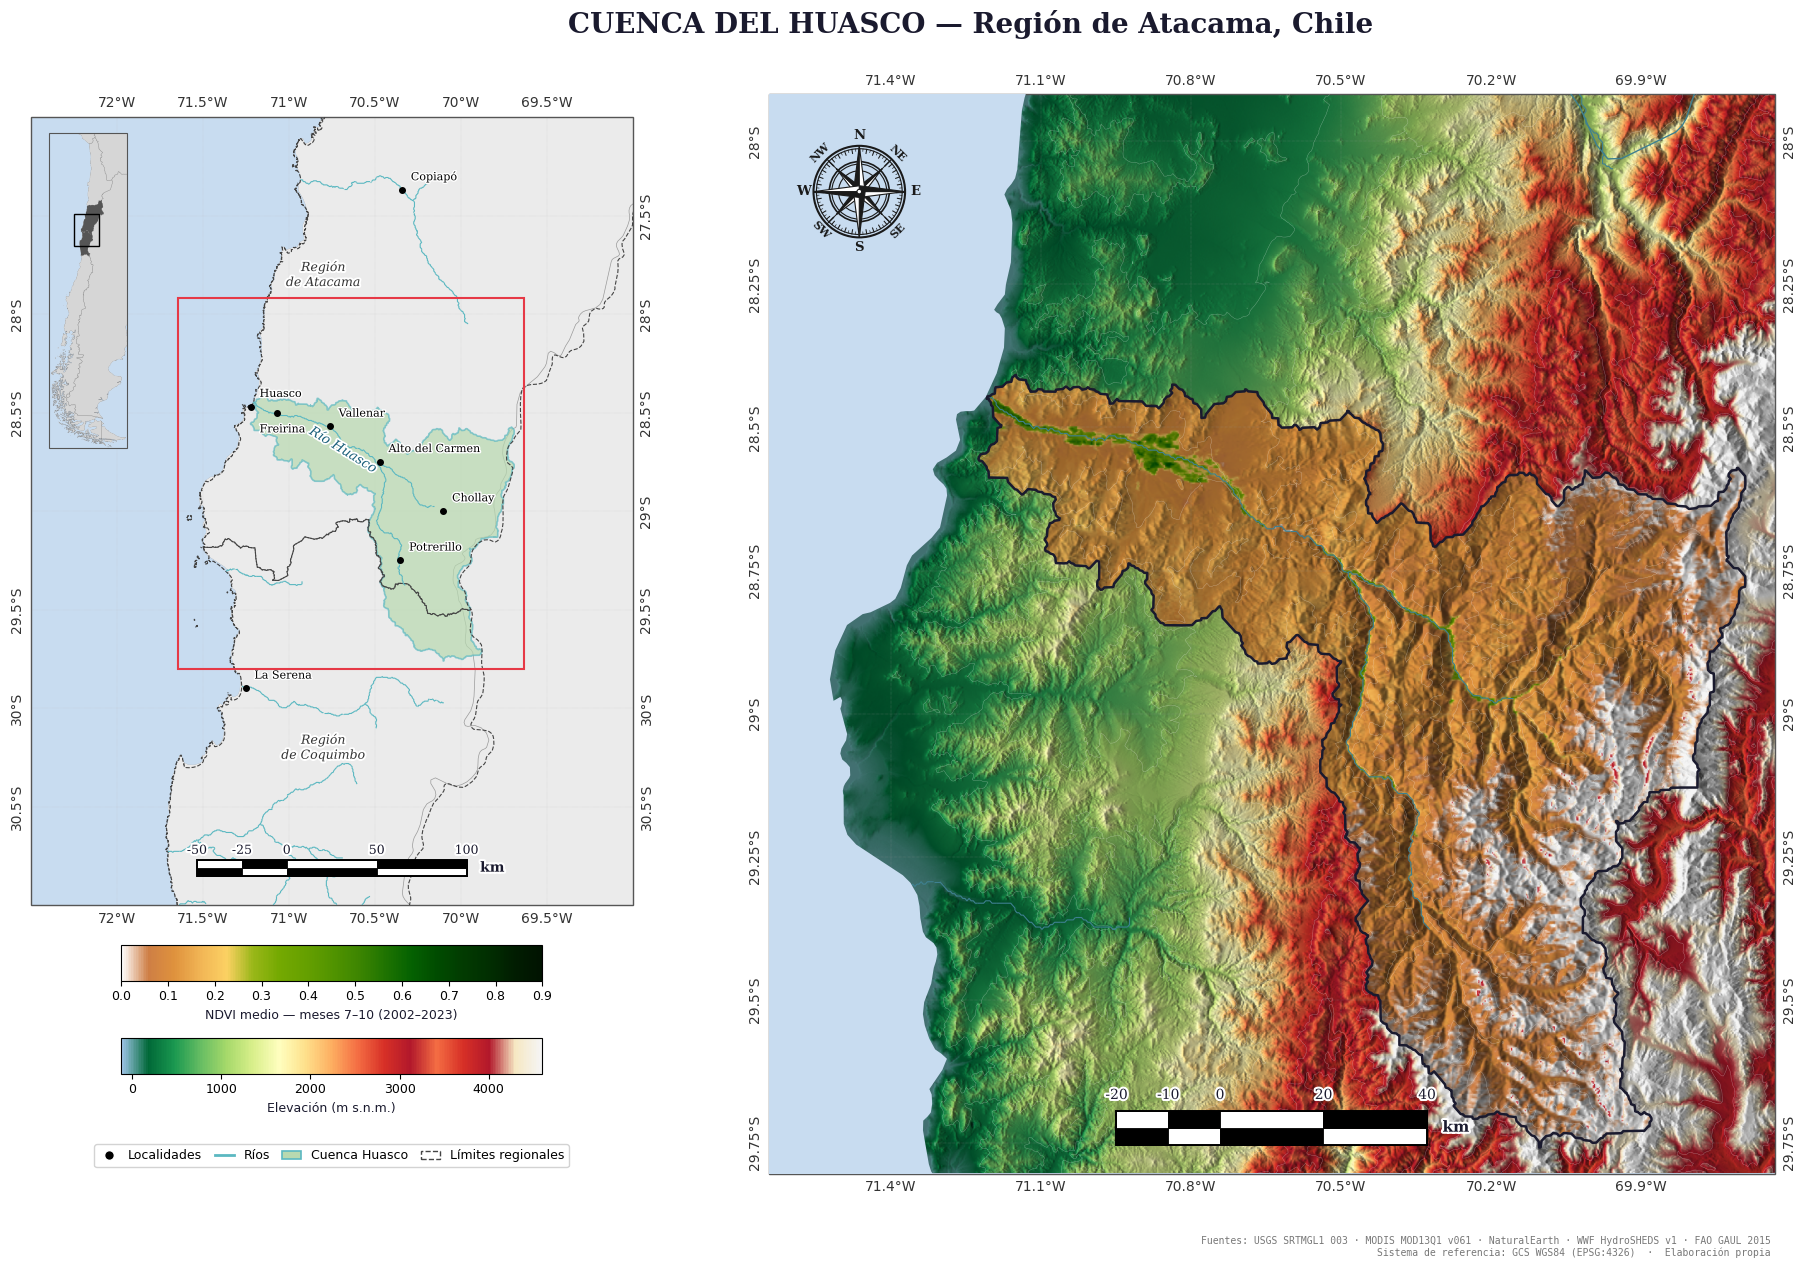

✅ Layout generado.


In [39]:
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from shapely.geometry import box as shapely_box
import cartopy.feature as cfeature

CRS = ccrs.PlateCarree()
BG  = '#FFFFFF'

EXT_MAIN = [dem_ext[0], dem_ext[1], dem_ext[2], dem_ext[3]]
EXT_REG  = [-72.5, -69.0, -31.0, -27.0]
EXT_CHL  = [-76.0, -65.0, -56.0, -17.0]

rivers = cfeature.NaturalEarthFeature(
    category='physical', name='rivers_lake_centerlines',
    scale='10m', facecolor='none'
)

# ── Colormaps ─────────────────────────────────────────────────────────────────
paleta_elev = [
    '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
    '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
    '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
    '#f6e8c3', '#f5f5f5'
]
paleta_ndvi = [
    '#ffffff', '#ce7e45', '#df923d', '#f1b555', '#fcd163', '#99b718',
    '#74a901', '#66a000', '#529400', '#3e8601', '#207401', '#056201',
    '#004c00', '#023b01', '#012e01', '#011d01', '#011301'
]
sm_elev = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('elev', paleta_elev),
    norm=mcolors.Normalize(vmin=-120, vmax=4600)
)
sm_elev.set_array([])
sm_ndvi = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('ndvi', paleta_ndvi),
    norm=mcolors.Normalize(vmin=0, vmax=0.9)
)
sm_ndvi.set_array([])

def add_scalebar(ax, lat_bottom, total_km, n_body=4, n_talon=2,
                 height_deg=0.06, fontsize=10, units='km',
                 center_lon=None):
    """
    Barra de escala cartográfica con talón y cuerpo.
    - Talón : segmentos subdivididos a la IZQUIERDA del 0
    - Cuerpo: segmentos enteros a la DERECHA del 0
    center_lon : longitud del centro (None = centro del extent)
    """
    km_per_deg  = 111.32 * np.cos(np.radians(lat_bottom))
    seg_km      = total_km / n_body          # km por segmento del cuerpo
    seg_deg     = seg_km   / km_per_deg      # grados por segmento
    talon_deg   = seg_deg  / n_talon         # grados por subsegmento del talón
    talon_total = seg_deg                    # el talón ocupa 1 segmento completo
    body_deg    = seg_deg  * n_body          # longitud total del cuerpo
    total_deg   = talon_total + body_deg
    half_h      = height_deg / 2

    # Centrar en el 0 (origen de la barra)
    if center_lon is None:
        xlim       = ax.get_extent(crs=CRS)
        center_lon = (xlim[0] + xlim[1]) / 2

    lon_left = center_lon - total_deg / 2   # inicio del talón
    lon_zero = lon_left + talon_total        # posición del 0

    stroke = [pe.withStroke(linewidth=3, foreground='white')]

    # ══ TALÓN — segmentos subdivididos, alternados, a la izquierda del 0 ══════
    for i in range(n_talon):
        x0    = lon_left + i * talon_deg
        # Fila inferior: negro en par
        color_bot = 'black' if i % 2 == 0 else 'white'
        # Fila superior: invertido
        color_top = 'white' if i % 2 == 0 else 'black'

        ax.add_patch(mpatches.Rectangle(
            (x0, lat_bottom), talon_deg, half_h,
            facecolor=color_bot, edgecolor='black', linewidth=0.6,
            transform=CRS, zorder=10, clip_on=False
        ))
        ax.add_patch(mpatches.Rectangle(
            (x0, lat_bottom + half_h), talon_deg, half_h,
            facecolor=color_top, edgecolor='black', linewidth=0.6,
            transform=CRS, zorder=10, clip_on=False
        ))

    # ══ CUERPO — segmentos enteros, alternados, a la derecha del 0 ═══════════
    for i in range(n_body):
        x0        = lon_zero + i * seg_deg
        color_bot = 'black' if i % 2 == 0 else 'white'
        color_top = 'white' if i % 2 == 0 else 'black'

        ax.add_patch(mpatches.Rectangle(
            (x0, lat_bottom), seg_deg, half_h,
            facecolor=color_bot, edgecolor='black', linewidth=0.6,
            transform=CRS, zorder=10, clip_on=False
        ))
        ax.add_patch(mpatches.Rectangle(
            (x0, lat_bottom + half_h), seg_deg, half_h,
            facecolor=color_top, edgecolor='black', linewidth=0.6,
            transform=CRS, zorder=10, clip_on=False
        ))

    # ── Borde exterior completo ───────────────────────────────────────────────
    ax.add_patch(mpatches.Rectangle(
        (lon_left, lat_bottom), total_deg, height_deg,
        facecolor='none', edgecolor='black', linewidth=1.4,
        transform=CRS, zorder=11, clip_on=False
    ))

    # ── Etiquetas numéricas arriba ────────────────────────────────────────────
    y_label = lat_bottom + height_deg + 0.015

    # Talón — etiquetas negativas (subdivisiones)
    for i in range(n_talon + 1):
        x   = lon_left + i * talon_deg
        val = -int((n_talon - i) * seg_km / n_talon)
        ax.text(x, y_label, str(val),
                ha='center', va='bottom', fontsize=fontsize,
                color='#1A1A2E', transform=CRS, zorder=12,
                fontfamily='serif', clip_on=False,
                path_effects=stroke)

    # Cuerpo — etiquetas positivas (0 ya puesto en talón final)
    for i in range(1, n_body + 1):
        x   = lon_zero + i * seg_deg
        val = int(i * seg_km)
        ax.text(x, y_label, str(val),
                ha='center', va='bottom', fontsize=fontsize,
                color='#1A1A2E', transform=CRS, zorder=12,
                fontfamily='serif', clip_on=False,
                path_effects=stroke)

    # ── Etiqueta unidad a la derecha ──────────────────────────────────────────
    ax.text(lon_zero + body_deg + seg_deg * 0.15,
            lat_bottom + height_deg / 2,
            units,
            ha='left', va='center', fontsize=fontsize + 1,
            color='#1A1A2E', transform=CRS, zorder=12,
            fontfamily='serif', fontweight='bold', clip_on=False,
            path_effects=stroke)

# ── Función etiqueta de río siguiendo la línea ────────────────────────────────
def label_river(ax, gdf, bbox_coords, label, color='#1A5F7A',
                fontsize=9, offset_lat=0.03, tramo=(0.1, 0.4)):
    """
    Etiqueta un río siguiendo el ángulo de su geometría.
    bbox_coords : (lon_min, lat_min, lon_max, lat_max)
    tramo       : fracción (inicio, fin) del segmento para calcular ángulo
    """
    bbox  = shapely_box(*bbox_coords)
    subset = gdf[gdf.geometry.intersects(bbox)]

    if subset.empty:
        # Fallback: texto estático
        cx = (bbox_coords[0] + bbox_coords[2]) / 2
        cy = (bbox_coords[1] + bbox_coords[3]) / 2
        ax.text(cx, cy + offset_lat, label, fontsize=fontsize,
                color=color, fontstyle='italic', fontfamily='serif',
                transform=CRS, zorder=9,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
        return

    # Unir todas las geometrías del tramo y extraer coordenadas
    from shapely.ops import unary_union, linemerge
    merged = linemerge(unary_union(subset.geometry))
    if merged.geom_type == 'MultiLineString':
        merged = max(merged.geoms, key=lambda g: g.length)

    coords = list(merged.coords)
    n      = len(coords)
    i0     = int(n * tramo[0])
    i1     = int(n * tramo[1])
    p1     = coords[i0]
    p2     = coords[i1]

    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    if angle < -90 or angle > 90:
      angle += 180

    mid_lon = (p1[0] + p2[0]) / 2
    mid_lat = (p1[1] + p2[1]) / 2

    ax.text(mid_lon, mid_lat + offset_lat, label,
            fontsize=fontsize, color=color,
            fontstyle='italic', fontfamily='serif',
            rotation=angle, rotation_mode='anchor',
            ha='center', va='bottom',
            transform=CRS, zorder=9,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# ── Figura: 2 columnas, 2 filas ───────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13), facecolor=BG)

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[0.32, 0.68],
    height_ratios=[0.78, 0.22],
    hspace=0.02, wspace=0.0,
    left=0.03, right=0.97, top=0.90, bottom=0.07  # ← top de 0.93 a 0.90
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL IZQUIERDO — Regional
# ══════════════════════════════════════════════════════════════════════════════
ax_reg = fig.add_subplot(gs[0, 0], projection=CRS, facecolor='#C8DCF0')
ax_reg.set_extent(EXT_REG, crs=CRS)

ax_reg.add_feature(cfeature.LAND,    facecolor='#EBEBEB', edgecolor='#aaa', linewidth=0.3)
ax_reg.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_reg.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='#999')

huasco_gdf.plot(ax=ax_reg, color='#B8D9B0', edgecolor='#5BB8C1',
                linewidth=1.2, zorder=4, transform=CRS, alpha=0.7)
regiones_gdf.boundary.plot(ax=ax_reg, color='#444', linewidth=0.8,
                            linestyle='--', zorder=5, transform=CRS)
rios_gdf.plot(ax=ax_reg, color='#5BB8C1', linewidth=0.8, zorder=6, transform=CRS)

# Etiqueta río Huasco siguiendo la línea
label_river(ax_reg, rios_gdf,
            bbox_coords=(-71.5, -28.7, -70.3, -28.3),
            label='Río Huasco',
            color='#1A5F7A', fontsize=9.5,
            offset_lat=-0.1,
            tramo=(0.1, 0.4))

# Nombres de regiones
nombres_regiones = {
    'Región\nde Atacama':  (-70.8, -27.8),
    'Región\nde Coquimbo': (-70.8, -30.2),
}
for nombre, (lon, lat) in nombres_regiones.items():
    ax_reg.text(lon, lat, nombre, fontsize=9, fontstyle='italic',
                fontfamily='serif', color='#333', ha='center', va='center',
                transform=CRS, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground='white')])

# Ciudades
ciudades_reg = {
    'Vallenar':        (-70.76, -28.57, +0.05, +0.05),
    'Copiapó':         (-70.34, -27.37, +0.05, +0.05),
    'Freirina':        (-71.07, -28.50, -0.10, -0.10),
    'Huasco':          (-71.22, -28.47, +0.05, +0.05),
    'La Serena':       (-71.25, -29.90, +0.05, +0.05),
    'Alto del Carmen': (-70.47, -28.75, +0.05, +0.05),
    'Chollay':         (-70.10, -29.00, +0.05, +0.05),
    'Potrerillo':      (-70.35, -29.25, +0.05, +0.05),
}
for nombre, (lon, lat, dlon, dlat) in ciudades_reg.items():
    ax_reg.plot(lon, lat, 'ko', markersize=4, transform=CRS, zorder=7)
    ax_reg.text(lon + dlon, lat + dlat, nombre, fontsize=8,
                fontfamily='serif', transform=CRS, zorder=8,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# Cuadrícula
gl_r = ax_reg.gridlines(draw_labels=True, linewidth=0.3,
                         color='#bbb', alpha=0.8, linestyle=':')
gl_r.top_labels    = True
gl_r.bottom_labels = True
gl_r.left_labels   = True
gl_r.right_labels  = True
gl_r.xformatter = LONGITUDE_FORMATTER
gl_r.yformatter = LATITUDE_FORMATTER
gl_r.xlabel_style = {'size': 10, 'color': '#333'}
gl_r.ylabel_style = {'size': 10, 'color': '#333', 'rotation': 90}

# Recuadro zoom
x0, x1, y0, y1 = EXT_MAIN
ax_reg.add_patch(Rectangle(
    (x0, y0), x1-x0, y1-y0,
    linewidth=1.5, edgecolor='#E63946', facecolor='none',
    transform=CRS, zorder=9
))

# Panel regional
add_scalebar(ax_reg,
             lat_bottom = EXT_REG[2] + 0.15,
             total_km   = 100,
             n_body     = 2,
             n_talon    = 2,
             height_deg = 0.08,
             fontsize   = 9,
             units      = 'km')

# Inset Chile
ax_chl = ax_reg.inset_axes([-0.08, 0.58, 0.35, 0.40], projection=CRS)
ax_chl.set_extent(EXT_CHL, crs=CRS)
ax_chl.add_feature(cfeature.LAND,    facecolor='#D6D6D6', edgecolor='#888', linewidth=0.3)
ax_chl.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_chl.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#888')
regiones_gdf.plot(ax=ax_chl, color='#555', zorder=3, transform=CRS)
x0r, x1r, y0r, y1r = EXT_REG
ax_chl.add_patch(Rectangle(
    (x0r, y0r), x1r-x0r, y1r-y0r,
    linewidth=1.0, edgecolor='black', facecolor='none',
    transform=CRS, zorder=5
))
for spine in ax_chl.spines.values():
    spine.set_edgecolor('#555')
    spine.set_linewidth(0.8)

# ══════════════════════════════════════════════════════════════════════════════
# LEYENDA — debajo del panel izquierdo
# ══════════════════════════════════════════════════════════════════════════════
ax_leg = fig.add_subplot(gs[1, 0])
ax_leg.axis('off')

# Colorbar NDVI horizontal — mitad superior
cax_ndvi = inset_axes(ax_leg, width='70%', height='15%',
                       loc='upper center', borderpad=0.5)
cb_ndvi  = plt.colorbar(sm_ndvi, cax=cax_ndvi, orientation='horizontal')
cb_ndvi.set_label(
    f'NDVI medio — meses {MONTH_START}–{MONTH_END} ({YEAR_START}–{YEAR_END})',
    fontsize=9, color='#1A1A2E', labelpad=4
)
cb_ndvi.ax.tick_params(labelsize=9)

# Colorbar Elevación horizontal — debajo del NDVI
cax_elev = inset_axes(ax_leg, width='70%', height='15%',
                       loc='center', borderpad=0.5)
cb_elev  = plt.colorbar(sm_elev, cax=cax_elev, orientation='horizontal')
cb_elev.set_label('Elevación (m s.n.m.)', fontsize=9, color='#1A1A2E', labelpad=4)
cb_elev.ax.tick_params(labelsize=9)

# Leyenda de símbolos — parte inferior
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='k',
           markersize=7, label='Localidades'),
    Line2D([0],[0], color='#5BB8C1', linewidth=2, label='Ríos'),
    mpatches.Patch(facecolor='#B8D9B0', edgecolor='#5BB8C1',
                   linewidth=1.2, label='Cuenca Huasco'),
    mpatches.Patch(facecolor='none', edgecolor='#444',
                   linewidth=1, linestyle='--', label='Límites regionales'),
]
ax_leg.legend(handles=handles, loc='lower center', ncol=4,
              fontsize=9, frameon=True, framealpha=0.85,
              edgecolor='#ccc', bbox_to_anchor=(0.5, 0.0),
              columnspacing=1.0, handlelength=1.5)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL PRINCIPAL — ambas filas col 1
# ══════════════════════════════════════════════════════════════════════════════
ax_main = fig.add_subplot(gs[:, 1], projection=CRS, facecolor='#C8DCF0')
ax_main.set_extent(EXT_MAIN, crs=CRS)

ax_main.imshow(
    shaded_2d, extent=dem_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=1
)
ax_main.imshow(
    ndvi_2d, extent=ndvi_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=2
)

lon_arr = np.linspace(dem_ext[0], dem_ext[1], dem_2d.shape[1])
lat_arr = np.linspace(dem_ext[3], dem_ext[2], dem_2d.shape[0])
LON, LAT = np.meshgrid(lon_arr, lat_arr)
ax_main.contour(LON, LAT, dem_2d,
                levels=[500, 1000, 2000, 3000, 4000],
                colors='white', linewidths=0.3, alpha=0.4, transform=CRS, zorder=3)

ax_main.add_feature(rivers, edgecolor='#3e8090', linewidth=1.0, zorder=6)
rios_gdf.plot(ax=ax_main, color='#3e8090', linewidth=0.8, zorder=5, transform=CRS)
huasco_gdf.boundary.plot(ax=ax_main, color='#1A1A2E', linewidth=1.8,
                          zorder=6, transform=CRS)
ax_main.add_feature(cfeature.OCEAN, facecolor='#C8DCF0', zorder=7)

# Cuadrícula
gl_m = ax_main.gridlines(draw_labels=True, linewidth=0.35,
                          color='#999', alpha=0.7, linestyle=':')
gl_m.top_labels    = True
gl_m.bottom_labels = True
gl_m.left_labels   = True
gl_m.right_labels  = True
gl_m.xformatter = LONGITUDE_FORMATTER
gl_m.yformatter = LATITUDE_FORMATTER
gl_m.xlabel_style = {'size': 10, 'color': '#333'}
gl_m.ylabel_style = {'size': 10, 'color': '#333', 'rotation': 90}

add_north_arrow(
    ax_main,
    loc="top-left",
    size=0.06,
    pad=0.03,
    font_size=9.5
)

# Panel principal
add_scalebar(ax_main,
             lat_bottom = dem_ext[2] + 0.05,
             total_km   = 40,
             n_body     = 2,
             n_talon    = 2,
             height_deg = 0.06,
             fontsize   = 10,
             units      = 'km')

# ══════════════════════════════════════════════════════════════════════════════
# TÍTULO Y CRÉDITOS
# ══════════════════════════════════════════════════════════════════════════════
fig.text(0.5, 0.965, 'CUENCA DEL HUASCO — Región de Atacama, Chile',
         ha='center', va='top', fontsize=20, fontweight='bold',
         color='#1A1A2E', fontfamily='serif')

fig.text(0.9, 0.005,
    'Fuentes: USGS SRTMGL1 003 · MODIS MOD13Q1 v061 · NaturalEarth · WWF HydroSHEDS v1 · FAO GAUL 2015\n'
    'Sistema de referencia: GCS WGS84 (EPSG:4326)  ·  Elaboración propia',
    ha='right', va='bottom', fontsize=7, color='#777', fontfamily='monospace')

for ax in [ax_reg, ax_main]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
        spine.set_linewidth(1.0)

# Rotar etiquetas Y tras renderizar
fig.canvas.draw()
for label in gl_r.left_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')
for label in gl_m.right_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')

plt.show()
print('✅ Layout generado.')

## 6 · Exportar mapa a PNG (300 DPI)

In [ ]:
OUT = '/content/cartografia_huasco.png'

fig.savefig(OUT, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'✅ Guardado en: {OUT}')

from google.colab import files
files.download(OUT)